In [19]:
# Imports and Setup
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, func, distinct
from sqlalchemy.orm import sessionmaker, aliased
from models import News, NewsSecurities, Securities, HistPrice1D, IvSurf, Options
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Load environment variables and set up database connection
load_dotenv()

DB_SERVER = os.getenv('DB_SERVER')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_NAME = os.getenv('DB_NAME')

connection_string = f"mssql+pyodbc://{DB_USER}:{DB_PASSWORD}@{DB_SERVER}/{DB_NAME}?driver=ODBC+Driver+17+for+SQL+Server"

engine = create_engine(connection_string)
Session = sessionmaker(bind=engine)
session = Session()

# Set up matplotlib style
plt.style.use('ggplot')

1. Time Series Average Number of Options for Top 20 Stocks:
option_type   average_calls  average_puts       total  call_ratio
stock_ticker                                                     
NVDA             445.516854    381.295880  826.812734    0.538836
SMCI             328.459016    275.049180  603.508197    0.544249
MSTR             258.327869    236.409836  494.737705    0.522151
TSLA             263.172285    211.865169  475.037453    0.554003
AVGO             224.719101    218.438202  443.157303    0.507087
META             234.217228    195.250936  429.468165    0.545366
NFLX             200.535581    180.808989  381.344569    0.525865
AMD              196.790262    160.235955  357.026217    0.551193
ARM              170.920152    159.562738  330.482890    0.517183
BKNG             150.213483    169.910112  320.123596    0.469236
LLY              167.382022    150.161049  317.543071    0.527116
MSFT             161.685393    149.307116  310.992509    0.519901
CMG             

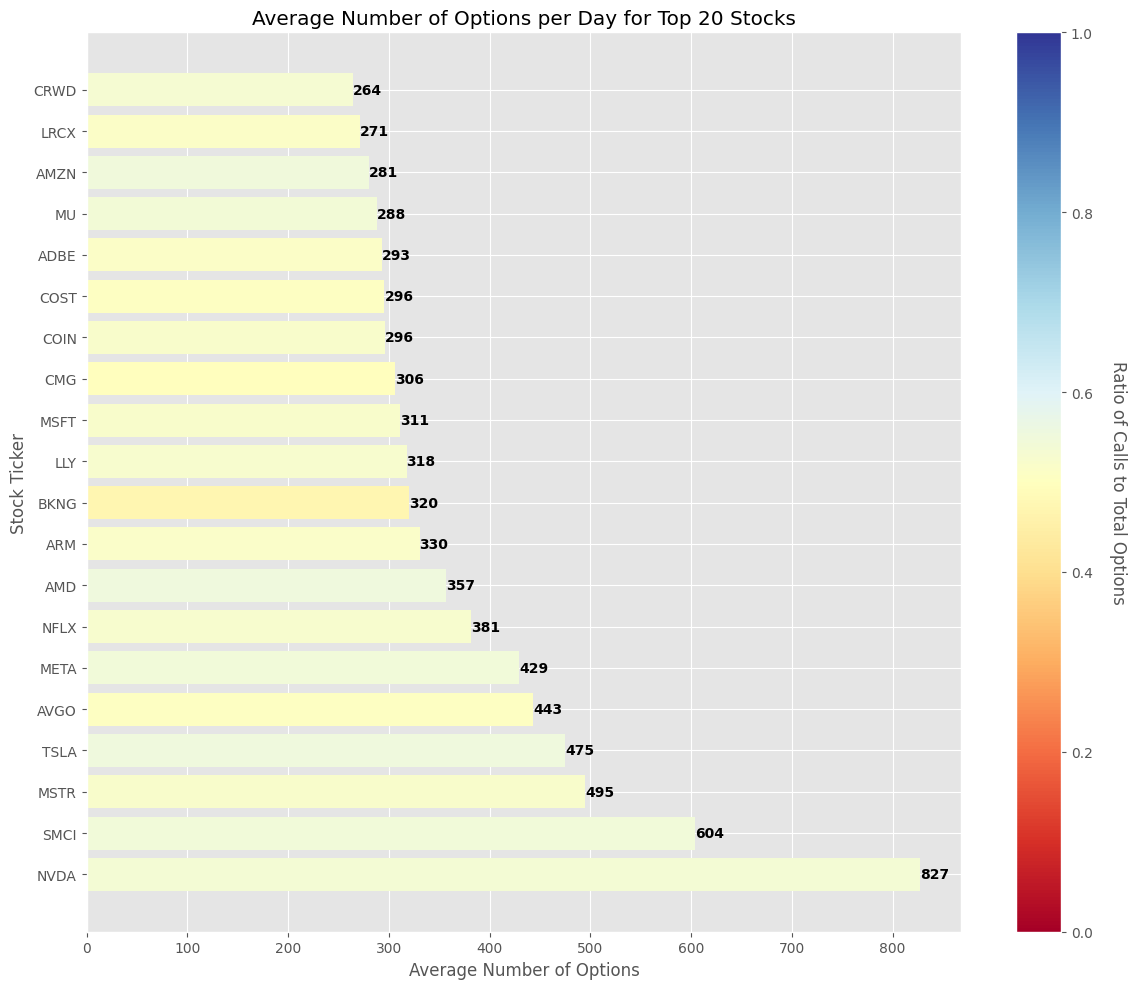

In [20]:
# 1. Options data analysis
SecuritiesOption = aliased(Securities)
SecuritiesStock = aliased(Securities)

options_query = (
    session.query(
        SecuritiesStock.ticker.label('stock_ticker'),
        Options.option_type,
        HistPrice1D.exch_time,
        func.count(Options.ticker).label('option_count')
    )
    .select_from(SecuritiesOption)
    .join(Options, SecuritiesOption.ticker == Options.ticker)
    .join(SecuritiesStock, SecuritiesOption.underlying_ticker == SecuritiesStock.ticker)
    .join(HistPrice1D, (HistPrice1D.ticker == Options.ticker) & (HistPrice1D.exch_time <= Options.expiry))
    .filter(SecuritiesOption.security_type == 'opt')
    .group_by(SecuritiesStock.ticker, Options.option_type, HistPrice1D.exch_time)
)

options_df = pd.read_sql(options_query.statement, session.bind)

# Calculate average number of options per day for each stock and option type
options_avg = options_df.groupby(['stock_ticker', 'option_type'])['option_count'].mean().unstack(fill_value=0)
options_avg = options_avg.rename(columns={'call': 'average_calls', 'put': 'average_puts'})
options_avg['total'] = options_avg['average_calls'] + options_avg['average_puts']
options_avg['call_ratio'] = options_avg['average_calls'] / options_avg['total']

# Sort by total and get top 20 stocks
top_20 = options_avg.sort_values('total', ascending=False).head(20)

print("1. Time Series Average Number of Options for Top 20 Stocks:")
print(top_20)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(top_20.index, top_20['total'], color=plt.cm.RdYlBu(top_20['call_ratio']))
ax.set_title('Average Number of Options per Day for Top 20 Stocks')
ax.set_xlabel('Average Number of Options')
ax.set_ylabel('Stock Ticker')

# Add value labels to the end of each bar
for i, bar in enumerate(bars):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
            f'{top_20["total"].iloc[i]:.0f}', 
            va='center', ha='left', fontweight='bold')

# Create a colorbar legend
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Ratio of Calls to Total Options', rotation=270, labelpad=25)

plt.tight_layout()
plt.show()


2. IV Surface Data Analysis:

Descriptive Statistics of Stocks with Incomplete IV Surface Data:
count    24.000000
mean      0.441386
std       0.411250
min       0.000000
25%       0.000000
50%       0.459274
75%       0.903077
max       0.977778
Name: iv_surf_proportion, dtype: float64

Number of stocks with complete IV surface data: 321
Number of stocks with incomplete IV surface data: 24

Bottom 20 Stocks with Lowest Proportion of IV Surface Data:
    ticker  iv_surf_proportion
62     KMX            0.000000
63     TSN            0.000000
211    RRC            0.000000
212   FITB            0.000000
213   CYTK            0.000000
232   APLS            0.000000
271    FHN            0.000000
325    WAL            0.000000
168   COTY            0.022222
189    EDU            0.111111
48     LII            0.288889
164    GIS            0.444444
243    ELV            0.474104
11     CME            0.553785
283    LIN            0.553785
192   RACE            0.741036
186   NTES      

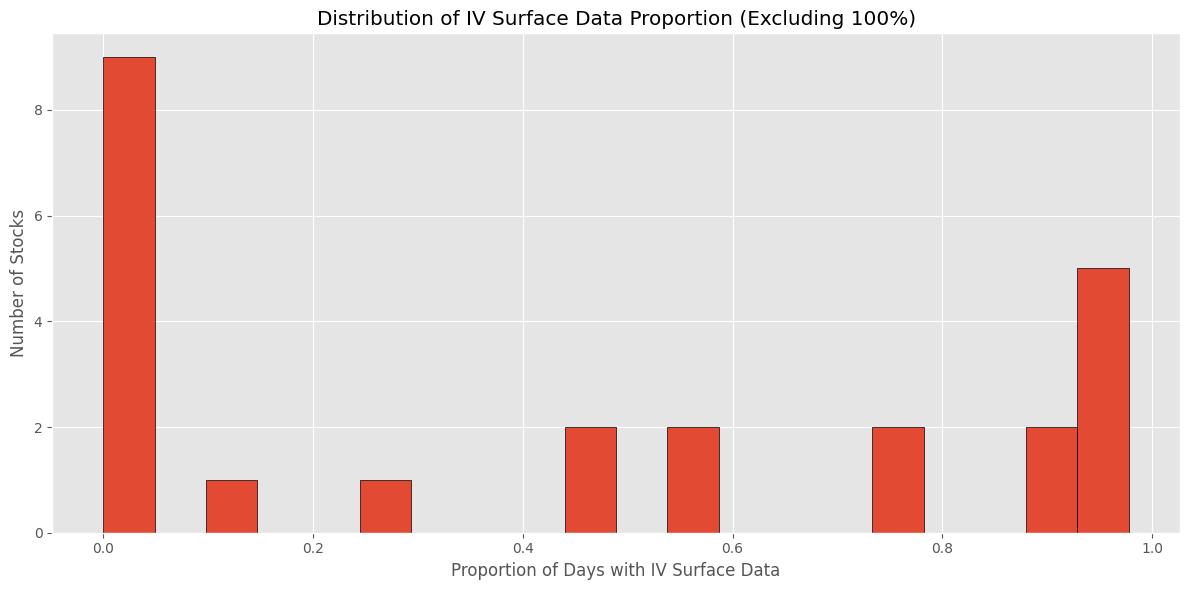

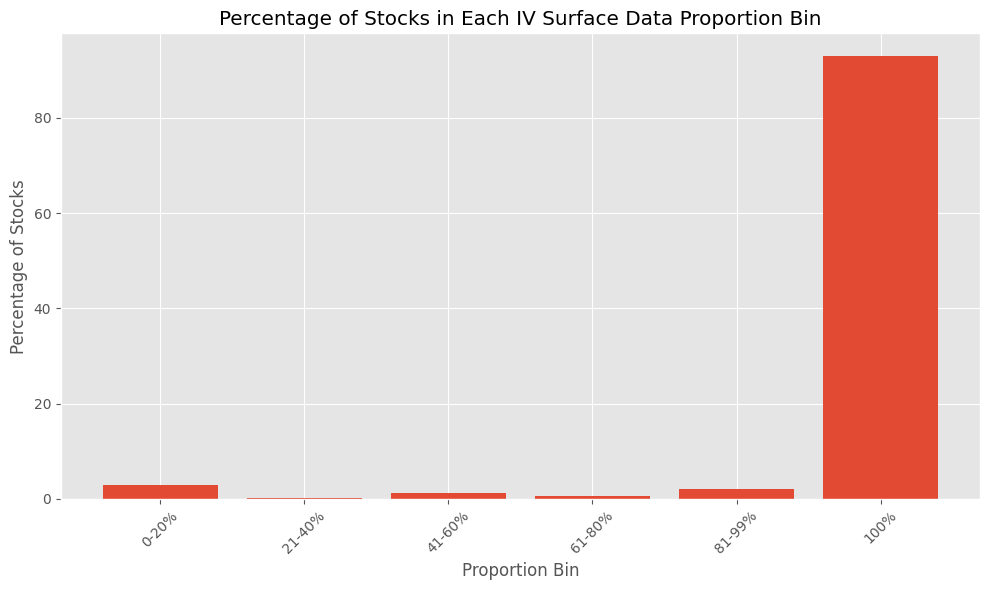

In [21]:
iv_surf_query = (
    session.query(
        Securities.ticker,
        func.count(distinct(IvSurf.exch_time)).label('days_with_iv_surf'),
        func.count(distinct(HistPrice1D.exch_time)).label('total_trading_days')
    )
    .join(IvSurf, Securities.ticker == IvSurf.ticker, isouter=True)
    .join(HistPrice1D, Securities.ticker == HistPrice1D.ticker)
    .filter(Securities.security_type == 'stk')
    .group_by(Securities.ticker)
)

iv_surf_df = pd.read_sql(iv_surf_query.statement, session.bind)

# Calculate the proportion of days with IV surface data
iv_surf_df['iv_surf_proportion'] = iv_surf_df['days_with_iv_surf'] / iv_surf_df['total_trading_days']

print("\n2. IV Surface Data Analysis:")

# Focus on stocks with incomplete data
incomplete_data = iv_surf_df[iv_surf_df['iv_surf_proportion'] < 1]
print("\nDescriptive Statistics of Stocks with Incomplete IV Surface Data:")
print(incomplete_data['iv_surf_proportion'].describe())

print(f"\nNumber of stocks with complete IV surface data: {(iv_surf_df['iv_surf_proportion'] == 1).sum()}")
print(f"Number of stocks with incomplete IV surface data: {len(incomplete_data)}")

print("\nBottom 20 Stocks with Lowest Proportion of IV Surface Data:")
print(iv_surf_df.nsmallest(20, 'iv_surf_proportion')[['ticker', 'iv_surf_proportion']])

# Create bins for proportion values
bins = [0, 0.2, 0.4, 0.6, 0.8, 0.99, 1]
labels = ['0-20%', '21-40%', '41-60%', '61-80%', '81-99%', '100%']
iv_surf_df['proportion_bin'] = pd.cut(iv_surf_df['iv_surf_proportion'], bins=bins, labels=labels, include_lowest=True)

print("\nDistribution of stocks across IV surface data proportion bins:")
print(iv_surf_df['proportion_bin'].value_counts().sort_index())

# Visualizations
plt.figure(figsize=(12, 6))
plt.hist(incomplete_data['iv_surf_proportion'], bins=20, edgecolor='black')
plt.title('Distribution of IV Surface Data Proportion (Excluding 100%)')
plt.xlabel('Proportion of Days with IV Surface Data')
plt.ylabel('Number of Stocks')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
bin_counts = iv_surf_df['proportion_bin'].value_counts().sort_index()
plt.bar(bin_counts.index, bin_counts.values / len(iv_surf_df) * 100)
plt.title('Percentage of Stocks in Each IV Surface Data Proportion Bin')
plt.xlabel('Proportion Bin')
plt.ylabel('Percentage of Stocks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.tight_layout()
plt.show()


3. News Sentiment Distribution:
count    64941.000000
mean        65.393249
std         17.118119
min         10.000000
25%         50.000000
50%         75.000000
75%         75.000000
max         95.000000
Name: sentiment, dtype: float64


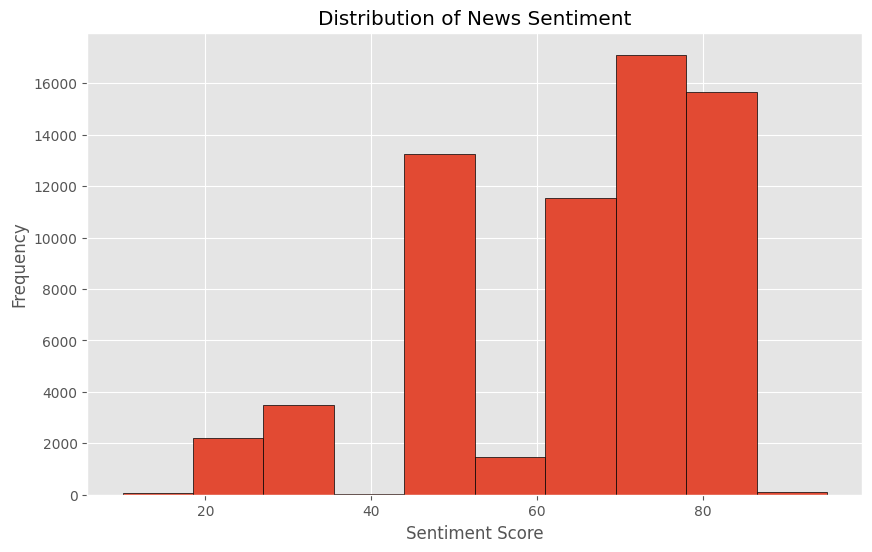

In [22]:
# 3. News data analysis
news_query = (
    session.query(News, NewsSecurities, Securities)
    .select_from(News)
    .join(NewsSecurities, News.id == NewsSecurities.news_id)
    .join(Securities, NewsSecurities.ticker == Securities.ticker)
)
df = pd.read_sql(news_query.statement, session.bind)

print("3. News Sentiment Distribution:")
print(df['sentiment'].describe())

# Plot
plt.figure(figsize=(10, 6))
df['sentiment'].hist(bins=10, edgecolor='black')
plt.title('Distribution of News Sentiment')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

4. Top 10 Most Mentioned Tickers:
ticker
NVDA    3524
TSLA    2897
INTC    1622
AMD     1583
META    1332
BA      1325
TSM     1127
AVGO    1118
MU       929
CRWD     905
Name: count, dtype: int64


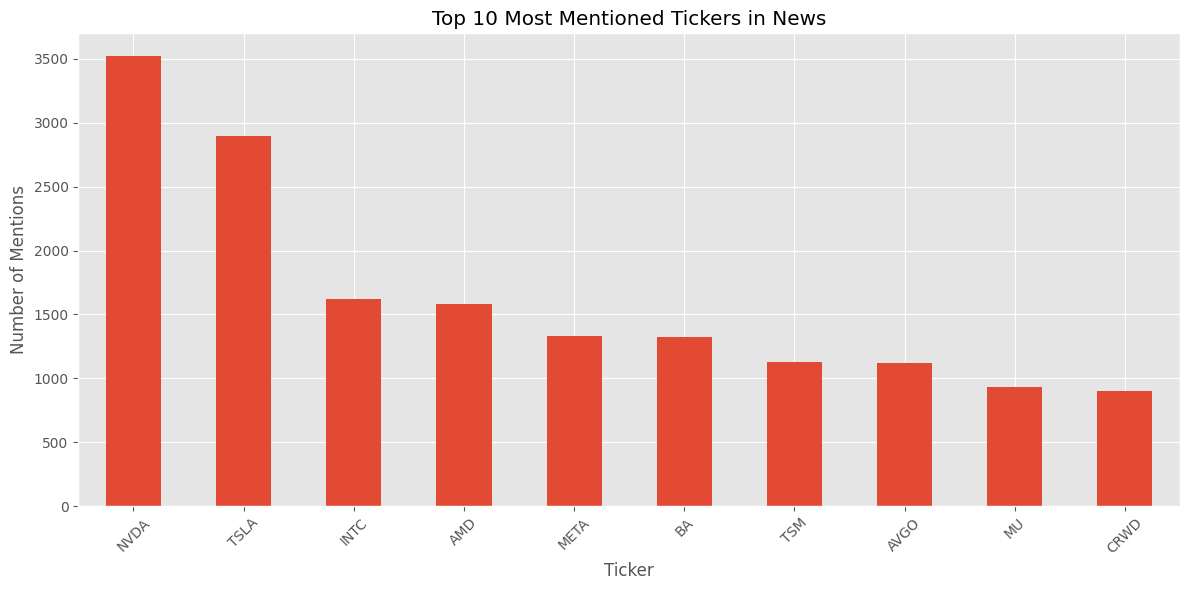

In [23]:
# 4. Top 10 most mentioned tickers in news
top_tickers = df['ticker'].value_counts().head(10)
print("4. Top 10 Most Mentioned Tickers:")
print(top_tickers)

# Plot
plt.figure(figsize=(12, 6))
top_tickers.plot(kind='bar')
plt.title('Top 10 Most Mentioned Tickers in News')
plt.xlabel('Ticker')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Average Sentiment for Top 10 Most Mentioned Tickers:
ticker
NVDA    70.724666
MU      70.660926
AVGO    70.369740
TSM     69.703638
CRWD    66.317127
AMD     64.856601
META    64.113363
INTC    54.654938
TSLA    53.640193
BA      47.178868
Name: sentiment, dtype: float64


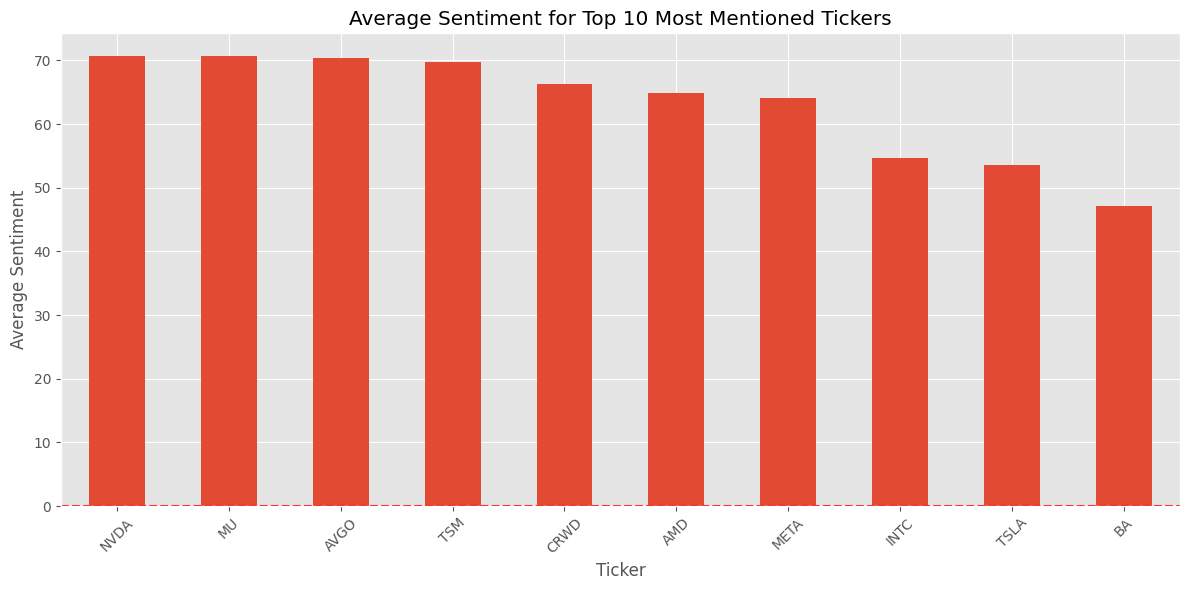

In [24]:
# 5. Average sentiment for top 10 most mentioned tickers
top_10_tickers = top_tickers.index
avg_sentiment = df[df['ticker'].isin(top_10_tickers)].groupby('ticker')['sentiment'].mean().sort_values(ascending=False)
print("5. Average Sentiment for Top 10 Most Mentioned Tickers:")
print(avg_sentiment)

# Plot
plt.figure(figsize=(12, 6))
avg_sentiment.plot(kind='bar')
plt.title('Average Sentiment for Top 10 Most Mentioned Tickers')
plt.xlabel('Ticker')
plt.ylabel('Average Sentiment')
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6. Average News Volume by Day of the Week:
day_of_week
Monday        80.231343
Tuesday       98.731343
Wednesday    105.664179
Thursday     101.671642
Friday        58.746269
Saturday      18.865672
Sunday        21.156716
dtype: float64


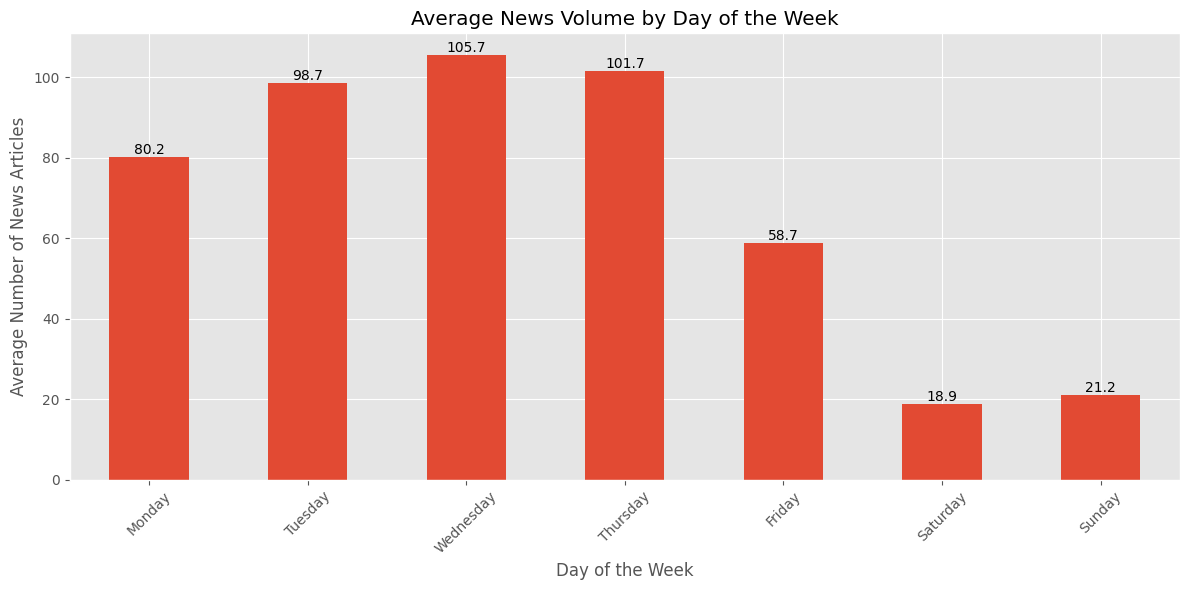

In [25]:
# 6. News volume by day of the week
df['date'] = pd.to_datetime(df['published_utc'])
df['day_of_week'] = df['date'].dt.day_name()

# Calculate average news volume for each day of the week
news_volume_by_day = df.groupby('day_of_week').size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
news_volume_by_day = news_volume_by_day / (df['date'].max() - df['date'].min()).days * 7  # Convert to daily average

print("6. Average News Volume by Day of the Week:")
print(news_volume_by_day)

# Plot
plt.figure(figsize=(12, 6))
bars = news_volume_by_day.plot(kind='bar')
plt.title('Average News Volume by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Number of News Articles')
plt.xticks(rotation=45)

# Add value labels on top of each bar
for i, v in enumerate(news_volume_by_day):
    plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

7. Descriptive Stats of Related Tickers per News Article:
count    55112.000000
mean         1.179398
std          0.575540
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         24.000000
Name: ticker, dtype: float64


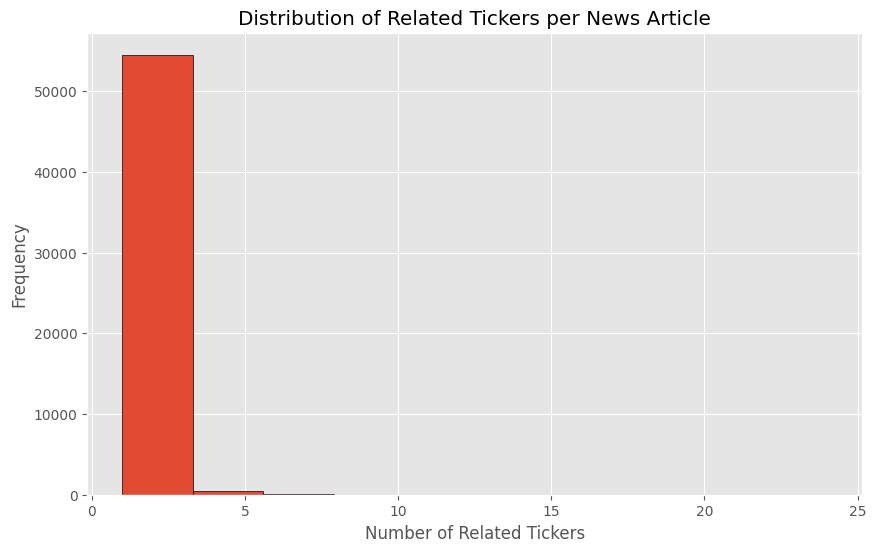

In [26]:
# 7. Descriptive stats about related tickers per news
tickers_per_news = df.groupby('id')['ticker'].count()
print("7. Descriptive Stats of Related Tickers per News Article:")
print(tickers_per_news.describe())

# Plot
plt.figure(figsize=(10, 6))
tickers_per_news.hist(bins=10, edgecolor='black')
plt.title('Distribution of Related Tickers per News Article')
plt.xlabel('Number of Related Tickers')
plt.ylabel('Frequency')
plt.show()

8. Analysis of News-Ticker Pairs With and Without Sentiment Scores:
Total number of news-ticker pairs: 64999
Number of news-ticker pairs with sentiment scores: 64941
Number of news-ticker pairs without sentiment scores: 58


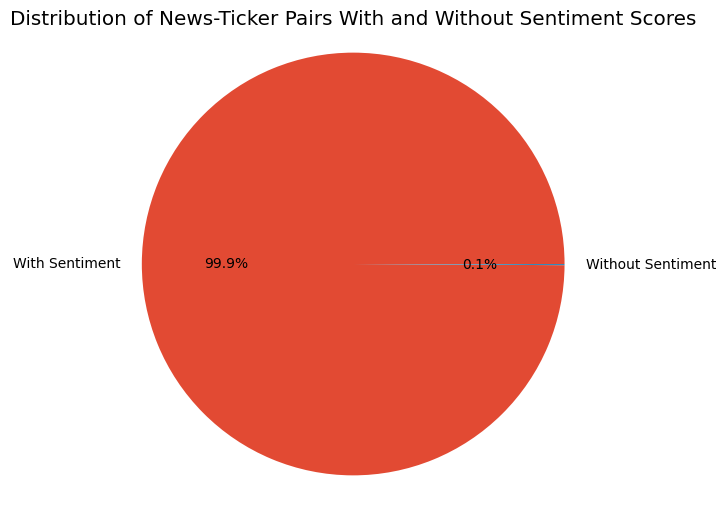

In [27]:
# 8. Analysis of news-ticker pairs with and without sentiment scores
print("8. Analysis of News-Ticker Pairs With and Without Sentiment Scores:")
total_pairs = len(df)
with_sentiment = df['sentiment'].notnull().sum()
without_sentiment = df['sentiment'].isnull().sum()

print(f"Total number of news-ticker pairs: {total_pairs}")
print(f"Number of news-ticker pairs with sentiment scores: {with_sentiment}")
print(f"Number of news-ticker pairs without sentiment scores: {without_sentiment}")

# Plot
plt.figure(figsize=(6, 6))
plt.pie([with_sentiment, without_sentiment], labels=['With Sentiment', 'Without Sentiment'], autopct='%1.1f%%')
plt.title('Distribution of News-Ticker Pairs With and Without Sentiment Scores')
plt.axis('equal')
plt.show()

# Close the session
session.close()